# Actividad 3.1 — Entrenamiento SVM para Detección de Peatones
### Navegación Autónoma — Maestría en Inteligencia Artificial

Este notebook entrena un clasificador SVM para detectar si una ventana de imagen contiene un peatón o no.  
El modelo entrenado se guarda como `pedestrian_svm.joblib` y es usado por `simple_controller_pedestrian.py`.

**Pipeline:**
```
Imágenes (64×128 px) → HOG (924 features) → SVM (RBF kernel) → persona / no persona
```

**Dataset local:** `human detection dataset/1/` (personas) y `human detection dataset/0/` (no personas)  
Fuente: https://www.kaggle.com/datasets/constantinwerner/human-detection-dataset

## 1. Importar bibliotecas

In [64]:
import glob
import numpy as np
import cv2
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print('Bibliotecas cargadas correctamente')

Bibliotecas cargadas correctamente


## 2. Cargar rutas del dataset

El dataset está organizado en dos carpetas:
- `1/` → imágenes **con** peatón (clase positiva)
- `0/` → imágenes **sin** peatón (clase negativa)

In [65]:
person_paths    = glob.glob('human detection dataset/1/*.png')
noperson_paths  = glob.glob('human detection dataset/0/*.png')

print(f'Imágenes con persona:    {len(person_paths)}')
print(f'Imágenes sin persona:    {len(noperson_paths)}')
print(f'Total:                   {len(person_paths) + len(noperson_paths)}')

Imágenes con persona:    1828
Imágenes sin persona:    1274
Total:                   3102


## 3. Ver ejemplos del dataset

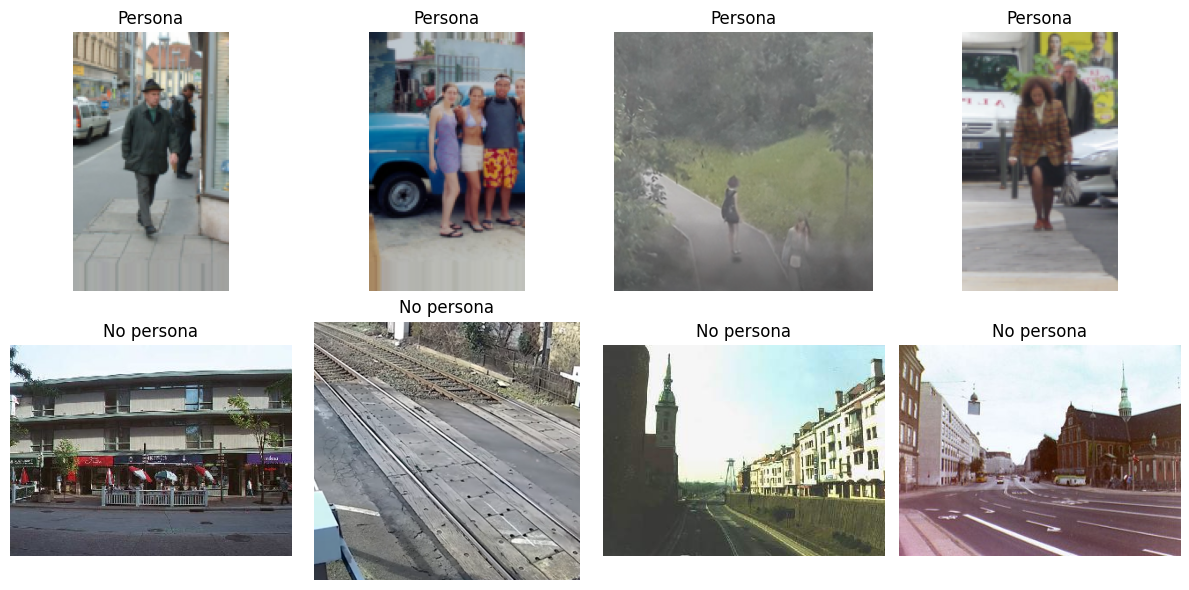

In [66]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, path in enumerate(person_paths[:4]):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Persona')
    axes[0, i].axis('off')
for i, path in enumerate(noperson_paths[:4]):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img)
    axes[1, i].set_title('No persona')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 4. Extraer características HOG

HOG (Histogram of Oriented Gradients) describe la forma de los objetos midiendo cuánto cambia el color/brillo en diferentes direcciones dentro de bloques de la imagen.  
Es especialmente bueno para detectar siluetas humanas porque captura la forma vertical del cuerpo.

**Parámetros usados:**
- `target_size = (64, 128)`: todas las imágenes se redimensionan a 64×128 px antes de calcular HOG, para que todos los vectores de características tengan el mismo tamaño (924 valores)
- `orientations=11`: mide gradientes en 11 direcciones distintas
- `pixels_per_cell=(16,16)`: cada celda cubre un bloque de 16×16 píxeles
- `cells_per_block=(2,2)`: normaliza grupos de 2×2 celdas para robustez ante iluminación

Estos parámetros son los mismos que Arturo validó en el notebook de referencia (`3.4_SVM_pedestrianArturo.ipynb`).

In [67]:
TARGET_SIZE = (64, 128)  # (ancho, alto) — convención de cv2.resize

def extract_hog_features(image_paths):
    """Carga imágenes, redimensiona y extrae vector HOG de cada una."""
    features = []
    skipped  = 0
    for path in image_paths:
        img = cv2.imread(path)
        if img is None:
            skipped += 1
            continue
        img  = cv2.resize(img, TARGET_SIZE)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        feat = hog(gray,
                   orientations=11,
                   pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2),
                   transform_sqrt=False,
                   feature_vector=True)
        features.append(feat)
    if skipped:
        print(f'  {skipped} imágenes no se pudieron cargar y se omitieron.')
    return np.vstack(features).astype(np.float64)

print('Extrayendo HOG — personas...')
X_person   = extract_hog_features(person_paths)
print(f'  X_person:   {X_person.shape}')

print('Extrayendo HOG — no personas...')
X_noperson = extract_hog_features(noperson_paths)
print(f'  X_noperson: {X_noperson.shape}')

Extrayendo HOG — personas...
  X_person:   (1828, 924)
Extrayendo HOG — no personas...
  X_noperson: (1274, 924)


## 5. Visualizar HOG de una imagen

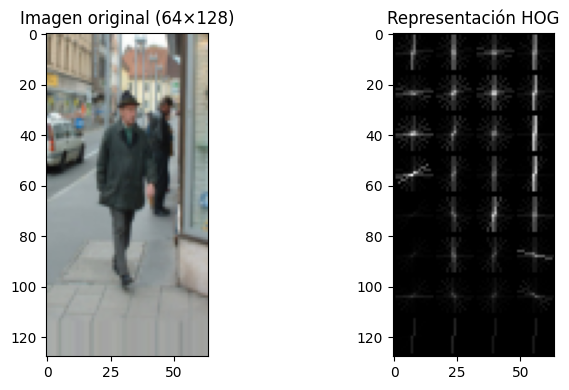

In [68]:
sample = cv2.resize(cv2.imread(person_paths[0]), TARGET_SIZE)
sample_gray = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)
_, hog_vis = hog(sample_gray, orientations=11,
                 pixels_per_cell=(16,16), cells_per_block=(2,2),
                 visualize=True, feature_vector=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
ax1.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
ax1.set_title('Imagen original (64×128)')
ax2.imshow(hog_vis, cmap='gray')
ax2.set_title('Representación HOG')
plt.tight_layout()
plt.show()

## 6. Combinar dataset y dividir en entrenamiento / prueba

In [69]:
X = np.vstack((X_person, X_noperson))
y = np.hstack((np.ones(len(X_person)), np.zeros(len(X_noperson))))

print(f'Dataset completo: {X.shape}  |  clases: {np.unique(y, return_counts=True)}')

# stratify=y mantiene la proporción 1/0 igual en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Dataset completo: (3102, 924)  |  clases: (array([0., 1.]), array([1274, 1828]))
Train: (2171, 924)  |  Test: (931, 924)


## 7. Entrenar SVM con GridSearchCV

Buscamos los mejores parámetros `C` y `gamma` para **nuestro** dataset específico.  
Los parámetros del notebook de Arturo (C=1, gamma=0.1) fueron optimizados con el doble de imágenes — no son necesariamente los mejores para 921 muestras.

El grid search corre con `scoring='f1'` igual que Arturo: prioriza el balance entre precisión y recall en la clase peatón.

**Convención de nombres en Pipeline:** los parámetros del SVM se escriben como `svc__C` y `svc__gamma` (nombre del paso + doble guion + parámetro).

In [70]:
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svc',    SVC(class_weight={0: 1, 1: 3}))
])

param_grid = {
    'svc__C':      [0.1, 1, 10, 100],
    'svc__gamma':  ['scale', 0.001, 0.01, 0.1],
    'svc__kernel': ['rbf', 'linear']
}

grid = GridSearchCV(pipeline, param_grid, scoring='f1', cv=5, refit=True, verbose=2)
grid.fit(X_train, y_train)

print(f'\nMejores parámetros: {grid.best_params_}')
print(f'Mejor F1 (cv):      {grid.best_score_:.4f}')

svm_model = grid.best_estimator_

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   0.8s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   0.8s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   0.8s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   0.8s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   0.8s
[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   0.3s
[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   0.3s
[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   0.3s
[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   0.3s
[CV] END ...svc__C=0.1, svc__gamma=scale, svc__kernel=linear; total time=   0.2s
[CV] END ......svc__C=0.1, svc__gamma=0.001, svc__kernel=rbf; total time=   0.8s
[CV] END ......svc__C=0.1, svc__gamma=0.001, sv

## 8. Evaluar el modelo

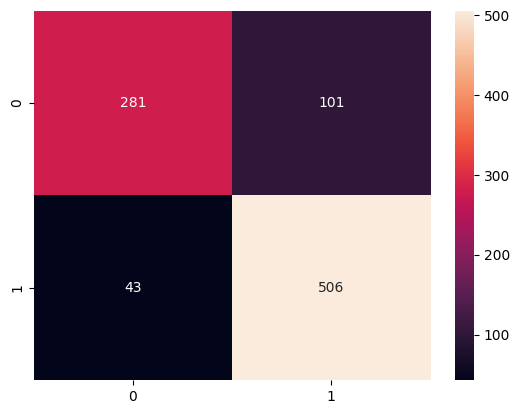

              precision    recall  f1-score   support

         0.0       0.87      0.74      0.80       382
         1.0       0.83      0.92      0.88       549

    accuracy                           0.85       931
   macro avg       0.85      0.83      0.84       931
weighted avg       0.85      0.85      0.84       931

Accuracy: 0.8453


In [71]:
predictions = svm_model.predict(X_test)

cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

# Precision = TP / (TP+FP)
# Recall    = TP / (TP+FN)
# Accuracy  = (TP + TN) / (TP + TN + FP + FN)
# F1        = 2 * (precision * recall) / (precision + recall)

print(classification_report(y_test, predictions))
print(f'Accuracy: {accuracy_score(y_test, predictions):.4f}')

## 9. Guardar modelo

El modelo se guarda en `pedestrian_svm.joblib` junto a este notebook.  
El controlador `simple_controller_pedestrian.py` lo carga automáticamente desde esa ruta.

In [72]:
MODEL_OUT = 'pedestrian_svm.joblib'
joblib.dump(svm_model, MODEL_OUT)
print(f'Modelo guardado en: {MODEL_OUT}')

# Verificar que carga correctamente
loaded = joblib.load(MODEL_OUT)
sample_pred = loaded.predict([X_test[0]])
print(f'Verificación — predicción de prueba: {sample_pred[0]} (real: {y_test[0]})')

Modelo guardado en: pedestrian_svm.joblib
Verificación — predicción de prueba: 1.0 (real: 1.0)
